<a href="https://colab.research.google.com/github/baoan056788/THDeppLearning/blob/main/Buoi3_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cài thư viện cần thiết
!pip install -q scikeras

# =========================
# Import required libraries
# =========================

# Data processing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Keras wrapper for scikit-learn
from scikeras.wrappers import KerasClassifier

# Model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   Label  Description
0      0  T-shirt/top
1      1      Trouser
2      2     Pullover
3      3        Dress
4      4         Coat
5      5       Sandal
6      6        Shirt
7      7      Sneaker
8      8          Bag
9      9   Ankle boot
Kích thước X_train: (60000, 28, 28)
Kích thước y_train: (60000,)
Kích thước X_test: (10000, 28, 28)
Kích thước y_test: (10000,)
Giá trị pixel nhỏ nhất: 0
Giá trị pixel lớn nhất: 255


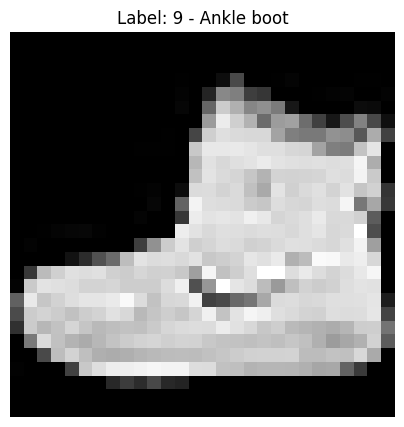

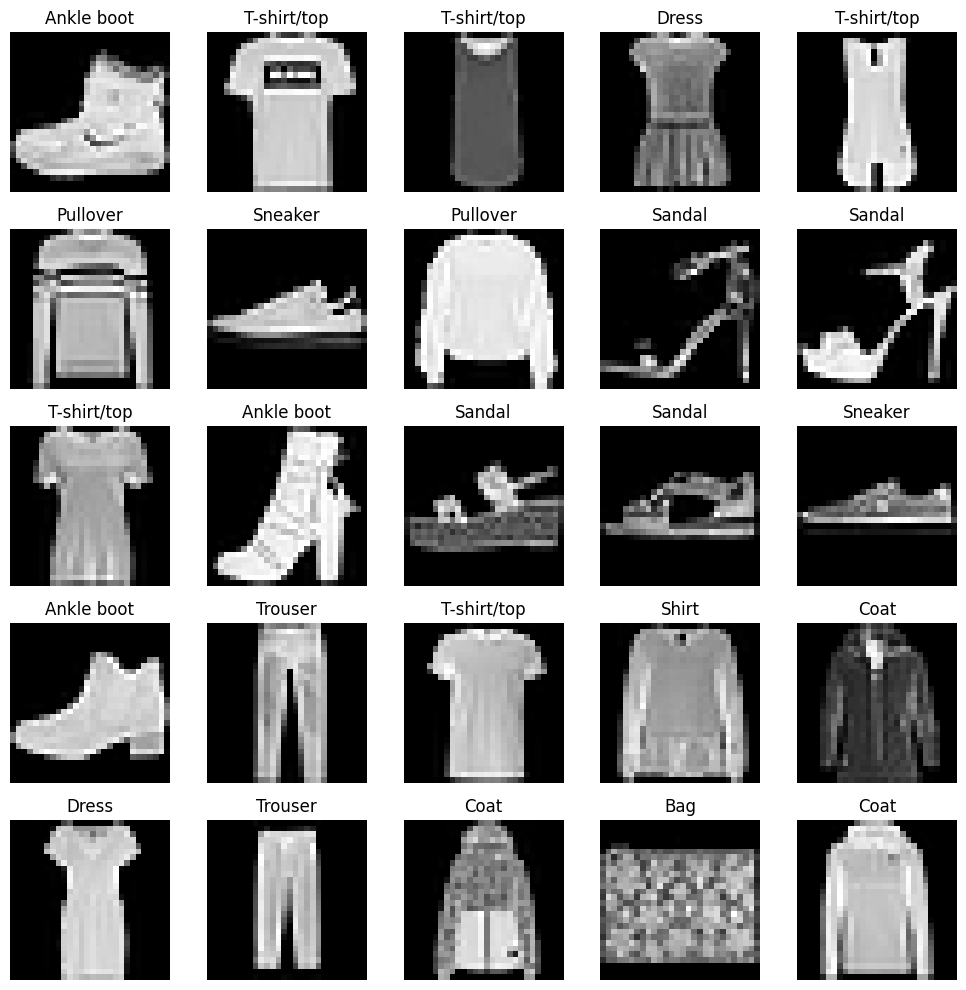

Sau tiền xử lý:
Kích thước X_train: (60000, 28, 28, 1)
Kích thước X_test: (10000, 28, 28, 1)
Giá trị pixel nhỏ nhất: 0.0
Giá trị pixel lớn nhất: 1.0


In [ ]:
# =========================
# 3.2. Đọc tập dữ liệu Fashion MNIST
# =========================

# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Khai báo tên các lớp nhãn
# =========================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# =========================
# Hiển thị bảng nhãn
# =========================

label_table = pd.DataFrame({
    "Label": list(range(10)),
    "Description": class_names
})

print(label_table)


# =========================
# Kiểm tra kích thước dữ liệu
# =========================

print("Kích thước X_train:", X_train.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước X_test:", X_test.shape)
print("Kích thước y_test:", y_test.shape)

print("Giá trị pixel nhỏ nhất:", X_train.min())
print("Giá trị pixel lớn nhất:", X_train.max())


# =========================
# Hiển thị một ảnh mẫu
# =========================

plt.figure(figsize=(5, 5))
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]} - {class_names[y_train[0]]}")
plt.axis("off")
plt.show()


# =========================
# Hiển thị nhiều ảnh mẫu
# =========================

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# Tiền xử lý dữ liệu
# =========================

# Chuẩn hóa giá trị pixel từ [0, 255] về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape dữ liệu để phù hợp với CNN
# Từ shape: (60000, 28, 28)
# Thành shape: (60000, 28, 28, 1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)


# =========================
# Kiểm tra lại dữ liệu sau tiền xử lý
# =========================

print("Sau tiền xử lý:")
print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test:", X_test.shape)
print("Giá trị pixel nhỏ nhất:", X_train.min())
print("Giá trị pixel lớn nhất:", X_train.max())

In [ ]:
#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()

X_train = minmax. fit_transform(X_train)
X_test = minmax. transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


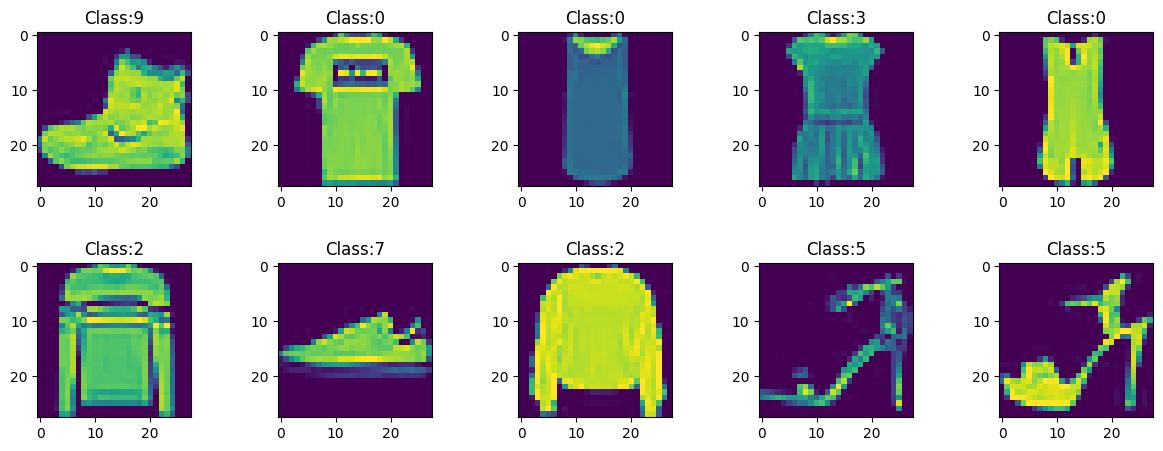

In [ ]:
#Data visualization
fig, axes = plt. subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
# =========================
# Import thư viện
# =========================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Khai báo tên lớp
# =========================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# =========================
# Tiền xử lý dữ liệu
# =========================

# Chuyển kiểu dữ liệu sang float32
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Làm phẳng ảnh 28x28 thành vector 784 chiều
X_train = X_train.reshape(X_train.shape[0], 28 * 28)
X_test = X_test.reshape(X_test.shape[0], 28 * 28)


# =========================
# Kiểm tra kích thước dữ liệu
# =========================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# =========================
# Initial ANN model
# =========================

fashion_model = Sequential()


# =========================
# Add first hidden layer
# =========================

fashion_model.add(Dense(
    units=256,
    input_dim=X_train.shape[1],
    kernel_initializer="uniform",
    activation="relu"
))


# =========================
# Add dropout layer
# =========================

fashion_model.add(Dropout(0.3))


# =========================
# Add second hidden layer
# =========================

fashion_model.add(Dense(
    units=128,
    kernel_initializer="uniform",
    activation="relu"
))


# =========================
# Add output layer
# =========================

fashion_model.add(Dense(
    units=10,
    kernel_initializer="uniform",
    activation="softmax"
))


# =========================
# Compile neural network
# =========================

fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# Model summary
# =========================

fashion_model.summary()


# =========================
# Train model
# =========================

history = fashion_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# =========================
# Evaluate model
# =========================

test_loss, test_accuracy = fashion_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


# =========================
# Predict sample
# =========================

index = 0

prediction = fashion_model.predict(X_test[index:index + 1])
predicted_label = np.argmax(prediction)

print("Nhãn dự đoán:", predicted_label, "-", class_names[predicted_label])
print("Nhãn thật:", y_test[index], "-", class_names[y_test[index]])

X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7838 - loss: 0.6006 - val_accuracy: 0.8383 - val_loss: 0.4359
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8470 - loss: 0.4196 - val_accuracy: 0.8511 - val_loss: 0.4038
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8624 - loss: 0.3754 - val_accuracy: 0.8676 - val_loss: 0.3622
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8685 - loss: 0.3563 - val_accuracy: 0.8777 - val_loss: 0.3501
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8745 - loss: 0.3394 - val_accuracy: 0.8781 - val_loss: 0.3418
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8774 - loss: 0.3274 - val_accuracy: 0.8769 - val_loss: 0.3360
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8819 - loss: 0.3143 - val_accuracy: 0.8838 - val_loss: 0.3173
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8863 - loss: 0.3049 - val_accuracy: 0.

In [ ]:
model_fit = fashion_model.fit(X_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8942 - loss: 0.2821 - val_accuracy: 0.8834 - val_loss: 0.3135
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8956 - loss: 0.2773 - val_accuracy: 0.8868 - val_loss: 0.3182
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8979 - loss: 0.2700 - val_accuracy: 0.8898 - val_loss: 0.3053
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9016 - loss: 0.2612 - val_accuracy: 0.8893 - val_loss: 0.3128
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9029 - loss: 0.2570 - val_accuracy: 0.8871 - val_loss: 0.3089
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9037 - loss: 0.2541 - val_accuracy: 0.8932 - val_loss: 0.3105
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9051 - loss: 0.2513 - val_accuracy: 0.8905 - val_loss: 0.3079
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9082 - loss: 0.2457 - val_accuracy: 0.

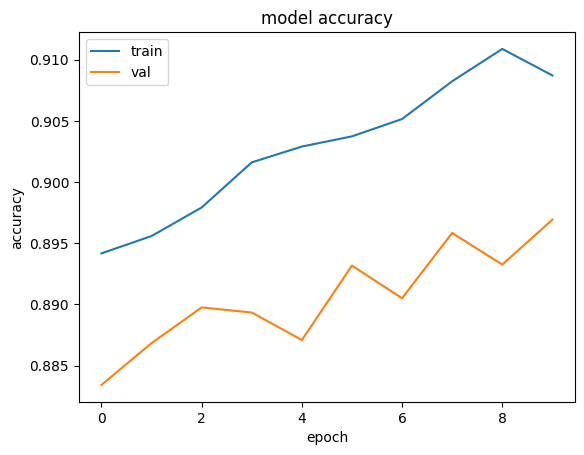

In [ ]:
plt.plot(model_fit.history['accuracy' ])
plt.plot(model_fit.history['val_accuracy'])
plt. title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt. legend(['train', 'val'], loc='upper left')
plt.show()

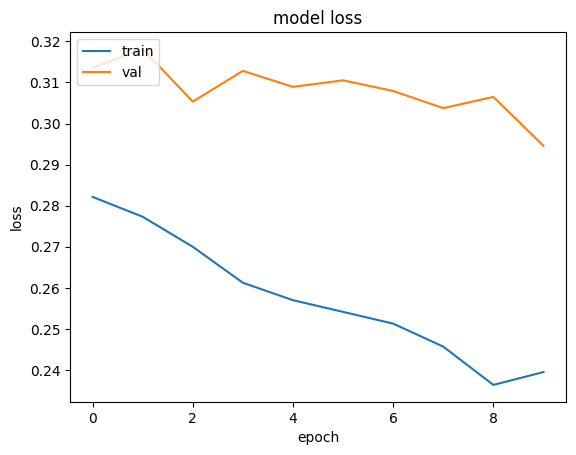

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss' ])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test) [10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [ ]:
# =========================
# Import thư viện
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Kiểm tra dữ liệu gốc
# =========================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
# =========================
# Chuyển dữ liệu ảnh thành dạng bảng giống CSV
# =========================

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

pixel_columns = [f"pixel{i}" for i in range(1, 785)]

mnist_train = pd.DataFrame(X_train_flat, columns=pixel_columns)
mnist_test = pd.DataFrame(X_test_flat, columns=pixel_columns)

mnist_train.insert(0, "label", y_train)
mnist_test.insert(0, "label", y_test)


# =========================
# Kiểm tra DataFrame
# =========================

print(mnist_train.head())
print(mnist_train.shape)

print(mnist_test.head())
print(mnist_test.shape)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      9       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       1       0       0   
2      0       0       0       0       0       0       0       0       0   
3      3       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...       119       114       130        76         0         0   
2       0  ...         0         0         1         0         0         0   
3      33  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [ ]:
# =========================
# Import thư viện
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Danh sách tên nhãn
# =========================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# =========================
# Chuyển dữ liệu về dạng bảng giống CSV
# =========================

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

pixel_columns = [f"pixel{i}" for i in range(1, 785)]

mnist_train = pd.DataFrame(X_train_flat, columns=pixel_columns)
mnist_test = pd.DataFrame(X_test_flat, columns=pixel_columns)

mnist_train.insert(0, "label", y_train)
mnist_test.insert(0, "label", y_test)


# =========================
# Kiểm tra dữ liệu
# =========================

print(mnist_train.head())
print("Train shape:", mnist_train.shape)
print("Test shape:", mnist_test.shape)


# =========================
# Tách X và y
# =========================

X_train = mnist_train.drop("label", axis=1).values
y_train = mnist_train["label"].values

X_test = mnist_test.drop("label", axis=1).values
y_test = mnist_test["label"].values


# =========================
# Chuẩn hóa dữ liệu
# =========================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# =========================
# Xây dựng mô hình ANN
# =========================

fashion_model = Sequential()

fashion_model.add(Dense(
    units=256,
    input_dim=X_train.shape[1],
    kernel_initializer="uniform",
    activation="relu"
))

fashion_model.add(Dropout(0.3))

fashion_model.add(Dense(
    units=128,
    kernel_initializer="uniform",
    activation="relu"
))

fashion_model.add(Dropout(0.3))

fashion_model.add(Dense(
    units=10,
    kernel_initializer="uniform",
    activation="softmax"
))


# =========================
# Compile model
# =========================

fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# Model summary
# =========================

fashion_model.summary()


# =========================
# Train model
# =========================

history = fashion_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# =========================
# Evaluate model
# =========================

test_loss, test_accuracy = fashion_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      9       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       1       0       0   
2      0       0       0       0       0       0       0       0       0   
3      3       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...       119       114       130        76         0         0   
2       0  ...         0         0         1         0         0         0   
3      33  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7680 - loss: 0.6349 - val_accuracy: 0.8449 - val_loss: 0.4228
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8431 - loss: 0.4368 - val_accuracy: 0.8521 - val_loss: 0.4074
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8557 - loss: 0.3944 - val_accuracy: 0.8676 - val_loss: 0.3595
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8644 - loss: 0.3718 - val_accuracy: 0.8761 - val_loss: 0.3451
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8698 - loss: 0.3563 - val_accuracy: 0.8763 - val_loss: 0.3454
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8764 - loss: 0.3403 - val_accuracy: 0.8780 - val_loss: 0.3355
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8785 - loss: 0.3311 - val_accuracy: 0.8776 - val_loss: 0.3280
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8814 - loss: 0.3194 - val_accuracy: 0.

In [ ]:
X_train = mnist_train.iloc[:,1:]
X_test = mnist_test. iloc[ :,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(60000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] )
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7896 - loss: 0.9409
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8281 - loss: 0.4985
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8370 - loss: 0.4792
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8416 - loss: 0.4710
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8450 - loss: 0.4575
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8479 - loss: 0.4515
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8500 - loss: 0.4444
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8513 - loss: 0.4378
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8526 - loss: 0.4358
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8539 - loss: 0.4359
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8551 - loss: 0.4281
Epoch 12/30
1875/1875 ━━━

In [ ]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])
print(np.argmax(model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving a4.jpg to a4.jpg


Shape ảnh đưa vào model: (1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
Kết quả xác suất: [[0.15423357 0.09948802 0.08186957 0.0625244  0.07702655 0.0043592
  0.07221225 0.01005711 0.4320125  0.00621683]]
Nhãn dự đoán: 8
Tên lớp dự đoán: Bag


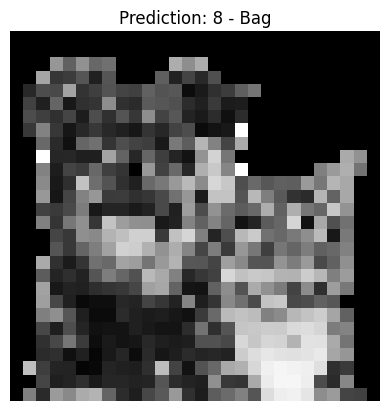

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Danh sách tên lớp của Fashion MNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Đường dẫn ảnh sau khi upload lên Colab
img_path = "/content/a4.jpg"

# Kích thước ảnh Fashion MNIST
img_size = (28, 28)

# Load ảnh grayscale và resize về 28x28
img = tf.keras.preprocessing.image.load_img(
    img_path,
    color_mode="grayscale",
    target_size=img_size
)

# Chuyển ảnh thành array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Đưa pixel về [0, 1]
img_array = img_array.astype("float32") / 255.0

# Vì model ANN nhận input dạng 784 chiều
img_array = img_array.reshape(1, 28 * 28)

print("Shape ảnh đưa vào model:", img_array.shape)

# Dự đoán
img_predict = fashion_model.predict(img_array)

print("Kết quả xác suất:", img_predict)

score = np.argmax(img_predict)

print("Nhãn dự đoán:", score)
print("Tên lớp dự đoán:", class_names[score])

# Hiển thị ảnh
plt.imshow(img_array.reshape(28, 28), cmap="gray")
plt.title(f"Prediction: {score} - {class_names[score]}")
plt.axis("off")
plt.show()

1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow
với các nhãn sau

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step
X_train shape ban đầu: (50000, 32, 32, 3)
y_train shape ban đầu: (50000, 1)
X_test shape ban đầu: (10000, 32, 32, 3)
y_test shape ban đầu: (10000, 1)
Giá trị pixel nhỏ nhất: 0
Giá trị pixel lớn nhất: 255


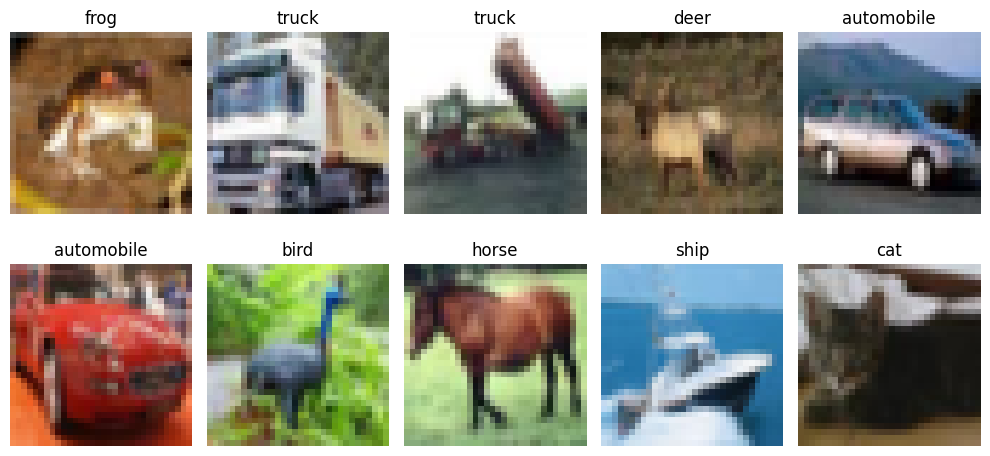

X_train shape sau xử lý: (50000, 3072)
y_train shape sau xử lý: (50000,)
X_test shape sau xử lý: (10000, 3072)
y_test shape sau xử lý: (10000,)
Giá trị pixel nhỏ nhất sau chuẩn hóa: 0.0
Giá trị pixel lớn nhất sau chuẩn hóa: 1.0


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - accuracy: 0.2292 - loss: 2.1079 - val_accuracy: 0.3360 - val_loss: 1.8728
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.2977 - loss: 1.9101 - val_accuracy: 0.3394 - val_loss: 1.8628
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.3136 - loss: 1.8725 - val_accuracy: 0.3577 - val_loss: 1.8044
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.3218 - loss: 1.8437 - val_accuracy: 0.3542 - val_loss: 1.8209
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.3304 - loss: 1.8195 - val_accuracy: 0.3711 - val_loss: 1.7510
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.3431 - loss: 1.7922 - val_accuracy: 0.3891 - val_loss: 1.7444
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.3471 - loss: 1.7840 - val_accuracy: 0.3930 - val_loss: 1.7304
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 104ms/step - accuracy: 0.3545 - loss: 1.7674

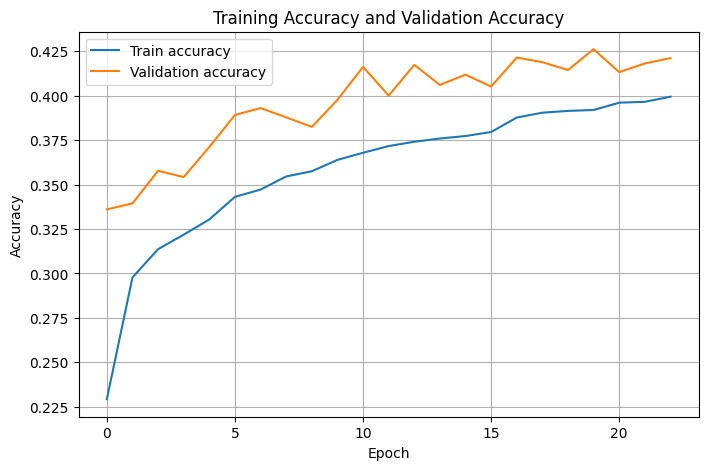

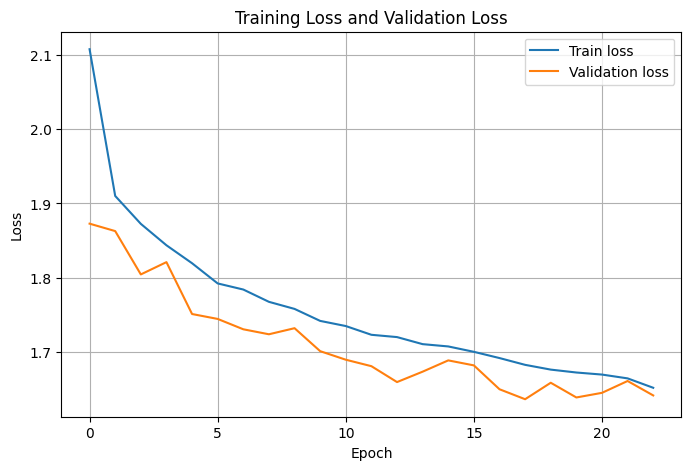

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Classification report:
              precision    recall  f1-score   support

    airplane       0.61      0.30      0.40      1000
  automobile       0.56      0.56      0.56      1000
        bird       0.29      0.11      0.16      1000
         cat       0.25      0.15      0.19      1000
        deer       0.32      0.51      0.39      1000
         dog       0.42      0.33      0.37      1000
        frog       0.36      0.59      0.45      1000
       horse       0.46      0.52      0.48      1000
        ship       0.48      0.67      0.56      1000
       truck       0.51      0.51      0.51      1000

    accuracy                           0.42     10000
   macro avg       0.43      0.42      0.41     10000
weighted avg       0.43      0.42      0.41     10000

Confusion matrix:
[[297  45  54  49  58   8  36  96 304  53]
 [ 17 557  12  37  18  12  35  31 107 174]
 [ 60  27 114  67 346  60 169  93  46  18]
 [  6  25  46 154 111 213 282

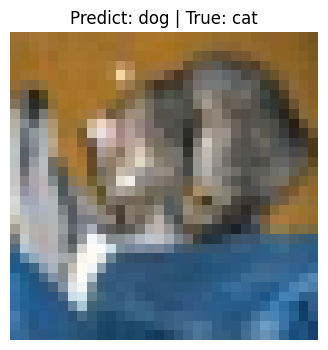

In [ ]:
# =========================
# 1. Import thư viện
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


# =========================
# 2. Đọc dataset CIFAR-10
# =========================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()


# =========================
# 3. Khai báo tên các lớp nhãn
# =========================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# =========================
# 4. Kiểm tra dữ liệu ban đầu
# =========================

print("X_train shape ban đầu:", X_train.shape)
print("y_train shape ban đầu:", y_train.shape)
print("X_test shape ban đầu:", X_test.shape)
print("y_test shape ban đầu:", y_test.shape)

print("Giá trị pixel nhỏ nhất:", X_train.min())
print("Giá trị pixel lớn nhất:", X_train.max())


# =========================
# 5. Hiển thị một số ảnh mẫu
# =========================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    label = int(y_train[i][0])
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# 6. Tiền xử lý dữ liệu
# =========================

# Chuyển nhãn từ shape (50000, 1) thành (50000,)
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Làm phẳng ảnh 32x32x3 thành vector 3072 chiều
X_train = X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test = X_test.reshape(X_test.shape[0], 32 * 32 * 3)


# =========================
# 7. Kiểm tra dữ liệu sau tiền xử lý
# =========================

print("X_train shape sau xử lý:", X_train.shape)
print("y_train shape sau xử lý:", y_train.shape)
print("X_test shape sau xử lý:", X_test.shape)
print("y_test shape sau xử lý:", y_test.shape)

print("Giá trị pixel nhỏ nhất sau chuẩn hóa:", X_train.min())
print("Giá trị pixel lớn nhất sau chuẩn hóa:", X_train.max())


# =========================
# 8. Xây dựng mô hình ANN
# =========================

ann_model = Sequential()

ann_model.add(Input(shape=(3072,)))

ann_model.add(Dense(
    units=1024,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=512,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=256,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=10,
    activation="softmax"
))


# =========================
# 9. Compile mô hình
# =========================

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# 10. Hiển thị kiến trúc mô hình
# =========================

ann_model.summary()


# =========================
# 11. Huấn luyện mô hình
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# =========================
# 12. Đánh giá mô hình trên tập test
# =========================

test_loss, test_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


# =========================
# 13. Vẽ biểu đồ accuracy và loss
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 14. Dự đoán trên tập test
# =========================

y_pred_prob = ann_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)


# =========================
# 15. Báo cáo phân loại
# =========================

print("Classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


# =========================
# 16. Ma trận nhầm lẫn
# =========================

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)


# =========================
# 17. Dự đoán một ảnh bất kỳ trong tập test
# =========================

index = 0

sample = X_test[index].reshape(1, 3072)

prediction = ann_model.predict(sample)
predicted_label = np.argmax(prediction)

print("Nhãn dự đoán:", predicted_label, "-", class_names[predicted_label])
print("Nhãn thật:", y_test[index], "-", class_names[y_test[index]])

plt.figure(figsize=(4, 4))
plt.imshow(X_test[index].reshape(32, 32, 3))
plt.title(
    "Predict: " + class_names[predicted_label] +
    " | True: " + class_names[y_test[index]]
)
plt.axis("off")
plt.show()

In [ ]:
# =========================
# Import thư viện
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Kiểm tra dữ liệu gốc
# =========================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
# =========================
# Chuyển dữ liệu ảnh thành dạng bảng giống CSV
# =========================

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

pixel_columns = [f"pixel{i}" for i in range(1, 785)]

mnist_train = pd.DataFrame(X_train_flat, columns=pixel_columns)
mnist_test = pd.DataFrame(X_test_flat, columns=pixel_columns)

mnist_train.insert(0, "label", y_train)
mnist_test.insert(0, "label", y_test)


# =========================
# Kiểm tra DataFrame
# =========================

print(mnist_train.head())
print(mnist_train.shape)

print(mnist_test.head())
print(mnist_test.shape)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      9       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       1       0       0   
2      0       0       0       0       0       0       0       0       0   
3      3       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...       119       114       130        76         0         0   
2       0  ...         0         0         1         0         0         0   
3      33  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [ ]:
# =========================
# Import thư viện
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# =========================
# Đọc dữ liệu Fashion MNIST
# =========================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# =========================
# Danh sách tên nhãn
# =========================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# =========================
# Chuyển dữ liệu về dạng bảng giống CSV
# =========================

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

pixel_columns = [f"pixel{i}" for i in range(1, 785)]

mnist_train = pd.DataFrame(X_train_flat, columns=pixel_columns)
mnist_test = pd.DataFrame(X_test_flat, columns=pixel_columns)

mnist_train.insert(0, "label", y_train)
mnist_test.insert(0, "label", y_test)


# =========================
# Kiểm tra dữ liệu
# =========================

print(mnist_train.head())
print("Train shape:", mnist_train.shape)
print("Test shape:", mnist_test.shape)


# =========================
# Tách X và y
# =========================

X_train = mnist_train.drop("label", axis=1).values
y_train = mnist_train["label"].values

X_test = mnist_test.drop("label", axis=1).values
y_test = mnist_test["label"].values


# =========================
# Chuẩn hóa dữ liệu
# =========================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# =========================
# Xây dựng mô hình ANN
# =========================

fashion_model = Sequential()

fashion_model.add(Dense(
    units=256,
    input_dim=X_train.shape[1],
    kernel_initializer="uniform",
    activation="relu"
))

fashion_model.add(Dropout(0.3))

fashion_model.add(Dense(
    units=128,
    kernel_initializer="uniform",
    activation="relu"
))

fashion_model.add(Dropout(0.3))

fashion_model.add(Dense(
    units=10,
    kernel_initializer="uniform",
    activation="softmax"
))


# =========================
# Compile model
# =========================

fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# Model summary
# =========================

fashion_model.summary()


# =========================
# Train model
# =========================

history = fashion_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# =========================
# Evaluate model
# =========================

test_loss, test_accuracy = fashion_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      9       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       1       0       0   
2      0       0       0       0       0       0       0       0       0   
3      3       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...       119       114       130        76         0         0   
2       0  ...         0         0         1         0         0         0   
3      33  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7699 - loss: 0.6364 - val_accuracy: 0.8493 - val_loss: 0.4258
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8448 - loss: 0.4333 - val_accuracy: 0.8568 - val_loss: 0.3890
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8569 - loss: 0.3961 - val_accuracy: 0.8683 - val_loss: 0.3621
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8633 - loss: 0.3744 - val_accuracy: 0.8660 - val_loss: 0.3669
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8701 - loss: 0.3549 - val_accuracy: 0.8677 - val_loss: 0.3584
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8743 - loss: 0.3444 - val_accuracy: 0.8791 - val_loss: 0.3349
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8786 - loss: 0.3316 - val_accuracy: 0.8718 - val_loss: 0.3371
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8821 - loss: 0.3210 - val_accuracy: 

In [ ]:
X_train = mnist_train.iloc[:,1:]
X_test = mnist_test. iloc[ :,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(60000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] )
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7869 - loss: 1.0540
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8228 - loss: 0.4981
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8338 - loss: 0.4798
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8354 - loss: 0.4789
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8407 - loss: 0.4627
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8449 - loss: 0.4563
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8435 - loss: 0.4625
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8510 - loss: 0.4408
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8482 - loss: 0.4439
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8465 - loss: 0.4500
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8487 - loss: 0.4456
Epoch 12/30
1875/1875 ━

In [ ]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])
print(np.argmax(model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
4 4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving a.jpg to a.jpg


Shape ảnh đưa vào model: (1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Kết quả xác suất: [[1.1012366e-03 7.6031321e-15 1.0833577e-06 7.4267337e-12 1.6639262e-07
  2.7935152e-09 3.4768264e-06 2.7425414e-13 9.9889404e-01 1.7218801e-11]]
Nhãn dự đoán: 8
Tên lớp dự đoán: Bag


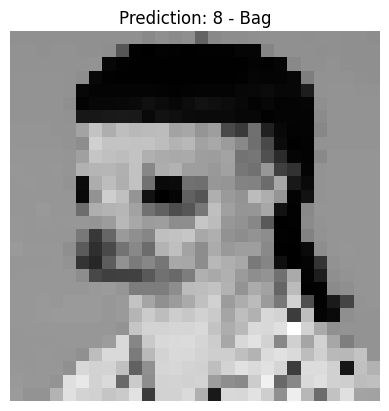

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Danh sách tên lớp của Fashion MNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Đường dẫn ảnh sau khi upload lên Colab
img_path = "/content/a.jpg"

# Kích thước ảnh Fashion MNIST
img_size = (28, 28)

# Load ảnh grayscale và resize về 28x28
img = tf.keras.preprocessing.image.load_img(
    img_path,
    color_mode="grayscale",
    target_size=img_size
)

# Chuyển ảnh thành array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Đưa pixel về [0, 1]
img_array = img_array.astype("float32") / 255.0

# Vì model ANN nhận input dạng 784 chiều
img_array = img_array.reshape(1, 28 * 28)

print("Shape ảnh đưa vào model:", img_array.shape)

# Dự đoán
img_predict = fashion_model.predict(img_array)

print("Kết quả xác suất:", img_predict)

score = np.argmax(img_predict)

print("Nhãn dự đoán:", score)
print("Tên lớp dự đoán:", class_names[score])

# Hiển thị ảnh
plt.imshow(img_array.reshape(28, 28), cmap="gray")
plt.title(f"Prediction: {score} - {class_names[score]}")
plt.axis("off")
plt.show()

Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau



X_train shape ban đầu: (50000, 32, 32, 3)
y_train shape ban đầu: (50000, 1)
X_test shape ban đầu: (10000, 32, 32, 3)
y_test shape ban đầu: (10000, 1)
Giá trị pixel nhỏ nhất: 0
Giá trị pixel lớn nhất: 255


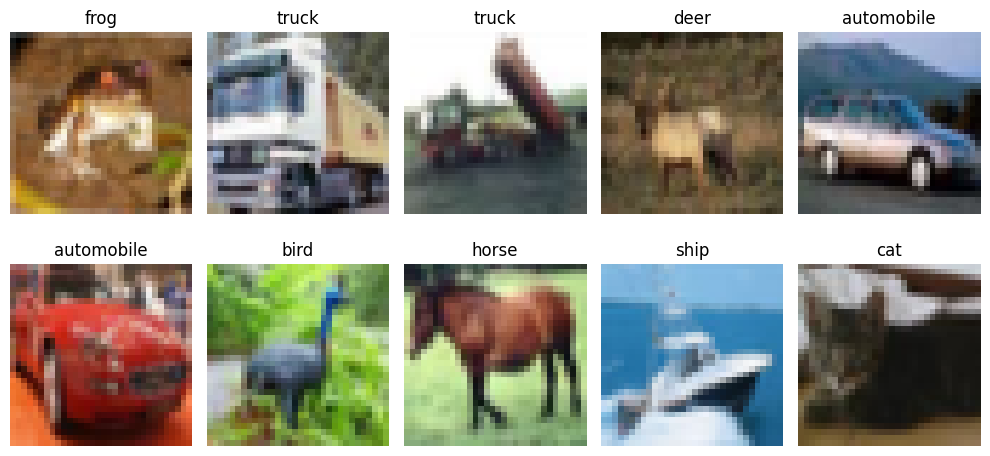

X_train shape sau xử lý: (50000, 3072)
y_train shape sau xử lý: (50000,)
X_test shape sau xử lý: (10000, 3072)
y_test shape sau xử lý: (10000,)
Giá trị pixel nhỏ nhất sau chuẩn hóa: 0.0
Giá trị pixel lớn nhất sau chuẩn hóa: 1.0


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.2252 - loss: 2.1308 - val_accuracy: 0.3112 - val_loss: 1.9102
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.2937 - loss: 1.9259 - val_accuracy: 0.3433 - val_loss: 1.8646
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.3099 - loss: 1.8846 - val_accuracy: 0.3564 - val_loss: 1.8087
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.3207 - loss: 1.8531 - val_accuracy: 0.3548 - val_loss: 1.8116
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.3257 - loss: 1.8379 - val_accuracy: 0.3705 - val_loss: 1.7753
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.3420 - loss: 1.8082 - val_accuracy: 0.3908 - val_loss: 1.7714
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.3490 - loss: 1.7916 - val_accuracy: 0.3958 - val_loss: 1.7468
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.3514 - loss: 1.7819 -

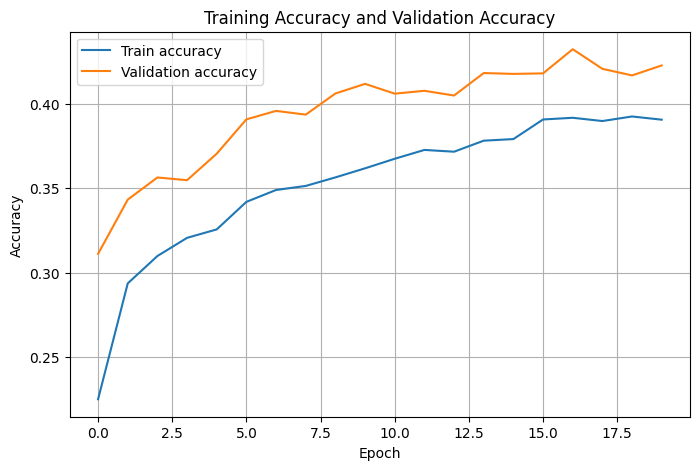

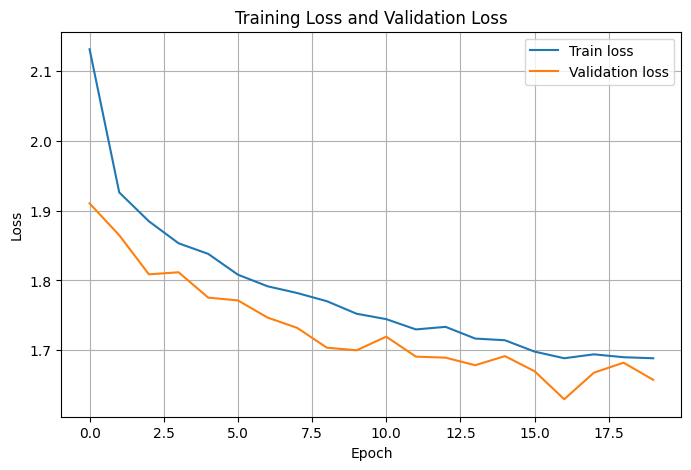

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Classification report:
              precision    recall  f1-score   support

    airplane       0.51      0.47      0.49      1000
  automobile       0.58      0.55      0.57      1000
        bird       0.32      0.17      0.22      1000
         cat       0.30      0.38      0.33      1000
        deer       0.33      0.50      0.40      1000
         dog       0.45      0.23      0.31      1000
        frog       0.45      0.48      0.47      1000
       horse       0.50      0.44      0.47      1000
        ship       0.48      0.61      0.53      1000
       truck       0.47      0.51      0.49      1000

    accuracy                           0.43     10000
   macro avg       0.44      0.43      0.43     10000
weighted avg       0.44      0.43      0.43     10000

Confusion matrix:
[[471  39  48  54  41  12  19  42 190  84]
 [ 32 551   6  43  26  14  21  21 112 174]
 [118  27 170 106 280  50 125  61  40  23]
 [ 28  20  60 375 102 102 131

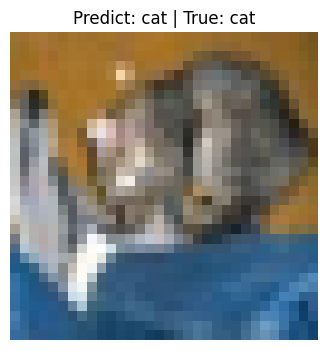

In [ ]:
# =========================
# 1. Import thư viện
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


# =========================
# 2. Đọc dataset CIFAR-10
# =========================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()


# =========================
# 3. Khai báo tên các lớp nhãn
# =========================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# =========================
# 4. Kiểm tra dữ liệu ban đầu
# =========================

print("X_train shape ban đầu:", X_train.shape)
print("y_train shape ban đầu:", y_train.shape)
print("X_test shape ban đầu:", X_test.shape)
print("y_test shape ban đầu:", y_test.shape)

print("Giá trị pixel nhỏ nhất:", X_train.min())
print("Giá trị pixel lớn nhất:", X_train.max())


# =========================
# 5. Hiển thị một số ảnh mẫu
# =========================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    label = int(y_train[i][0])
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# 6. Tiền xử lý dữ liệu
# =========================

# Chuyển nhãn từ shape (50000, 1) thành (50000,)
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Làm phẳng ảnh 32x32x3 thành vector 3072 chiều
X_train = X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test = X_test.reshape(X_test.shape[0], 32 * 32 * 3)


# =========================
# 7. Kiểm tra dữ liệu sau tiền xử lý
# =========================

print("X_train shape sau xử lý:", X_train.shape)
print("y_train shape sau xử lý:", y_train.shape)
print("X_test shape sau xử lý:", X_test.shape)
print("y_test shape sau xử lý:", y_test.shape)

print("Giá trị pixel nhỏ nhất sau chuẩn hóa:", X_train.min())
print("Giá trị pixel lớn nhất sau chuẩn hóa:", X_train.max())


# =========================
# 8. Xây dựng mô hình ANN
# =========================

ann_model = Sequential()

ann_model.add(Input(shape=(3072,)))

ann_model.add(Dense(
    units=1024,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=512,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=256,
    activation="relu",
    kernel_initializer="he_uniform"
))

ann_model.add(Dropout(0.3))

ann_model.add(Dense(
    units=10,
    activation="softmax"
))


# =========================
# 9. Compile mô hình
# =========================

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# 10. Hiển thị kiến trúc mô hình
# =========================

ann_model.summary()


# =========================
# 11. Huấn luyện mô hình
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# =========================
# 12. Đánh giá mô hình trên tập test
# =========================

test_loss, test_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


# =========================
# 13. Vẽ biểu đồ accuracy và loss
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 14. Dự đoán trên tập test
# =========================

y_pred_prob = ann_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)


# =========================
# 15. Báo cáo phân loại
# =========================

print("Classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


# =========================
# 16. Ma trận nhầm lẫn
# =========================

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)


# =========================
# 17. Dự đoán một ảnh bất kỳ trong tập test
# =========================

index = 0

sample = X_test[index].reshape(1, 3072)

prediction = ann_model.predict(sample)
predicted_label = np.argmax(prediction)

print("Nhãn dự đoán:", predicted_label, "-", class_names[predicted_label])
print("Nhãn thật:", y_test[index], "-", class_names[y_test[index]])

plt.figure(figsize=(4, 4))
plt.imshow(X_test[index].reshape(32, 32, 3))
plt.title(
    "Predict: " + class_names[predicted_label] +
    " | True: " + class_names[y_test[index]]
)
plt.axis("off")
plt.show()

2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST do giảng viên
cung cấp với các nhãn sau

In [ ]:
# =========================
# Tạo file mnist_train.csv từ TensorFlow/Keras
# =========================

import os
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist

# Đọc dataset MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Làm phẳng ảnh 28x28 thành 784 pixel
X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)

# Ghép nhãn vào cột đầu tiên
# Kết quả mỗi dòng: label, pixel1, pixel2, ..., pixel784
train_data = np.column_stack((y_train, X_train_flat))

# Lưu thành file CSV trong /content
np.savetxt(
    "/content/mnist_train.csv",
    train_data,
    fmt="%d",
    delimiter=","
)

# Kiểm tra file đã tạo
print("Đã tạo file:", "/content/mnist_train.csv")
print("File tồn tại:", os.path.exists("/content/mnist_train.csv"))

# Kiểm tra kích thước file CSV
mnist_train = pd.read_csv("/content/mnist_train.csv", header=None)

print("Shape:", mnist_train.shape)
print(mnist_train.head())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Đã tạo file: /content/mnist_train.csv
File tồn tại: True
Shape: (60000, 785)
   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0    5    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    4    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3    1    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4    9    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 785 columns]


In [ ]:
# =========================
# Tạo thêm file mnist_test.csv
# =========================

X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

test_data = np.column_stack((y_test, X_test_flat))

np.savetxt(
    "/content/mnist_test.csv",
    test_data,
    fmt="%d",
    delimiter=","
)

print("Đã tạo file:", "/content/mnist_test.csv")
print("File tồn tại:", os.path.exists("/content/mnist_test.csv"))

mnist_test = pd.read_csv("/content/mnist_test.csv", header=None)

print("Shape:", mnist_test.shape)
print(mnist_test.head())

Đã tạo file: /content/mnist_test.csv
File tồn tại: True
Shape: (10000, 785)
   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0    7    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    2    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    1    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4    4    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 785 columns]


Đã tìm thấy file MNIST CSV.
X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)
Pixel min: 0.0
Pixel max: 255.0
Nhãn train: [0 1 2 3 4 5 6 7 8 9]
Nhãn test: [0 1 2 3 4 5 6 7 8 9]


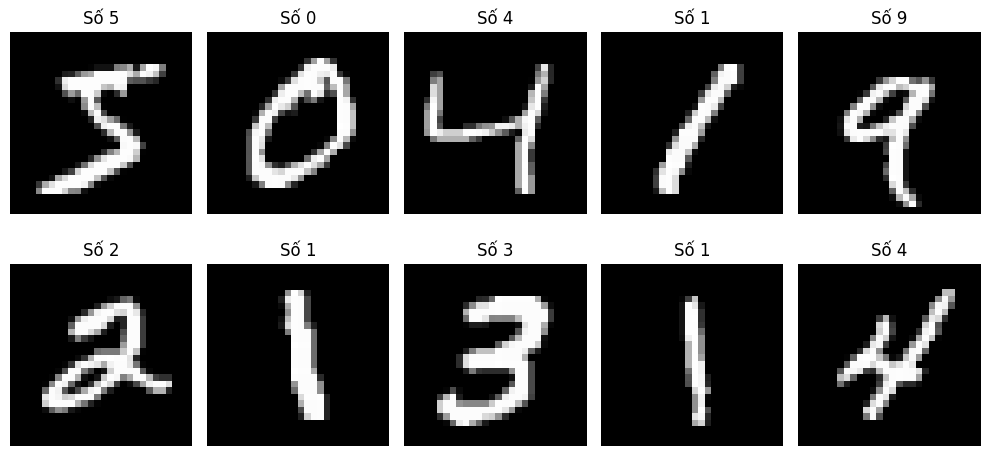

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,634 (2.21 MB)

 Trainable params: 576,842 (2.20 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/20
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7959 - loss: 0.6583
Epoch 1: val_accuracy improved from None to 0.96933, saving model to /content/best_mnist_ann_model.keras

Epoch 1: finished saving model to /content/best_mnist_ann_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8899 - loss: 0.3602 - val_accuracy: 0.9693 - val_loss: 0.0988 - learning_rate: 0.0010
Epoch 2/20
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9486 - loss: 0.1683
Epoch 2: val_accuracy improved from 0.96933 to 0.97633, saving model to /content/best_mnist_ann_model.keras

Epoch 2: finished saving model to /content/best_mnist_ann_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9518 - loss: 0.1564 - val_accuracy: 0.9763 - val_loss: 0.0808 - learning_rate: 0.0010
Epoch 3/20
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9625 - loss: 0.1196
Epoch 3: val_accuracy improved from 0.97633 to 0.97850, saving model to /content/best_mnist_ann_mod

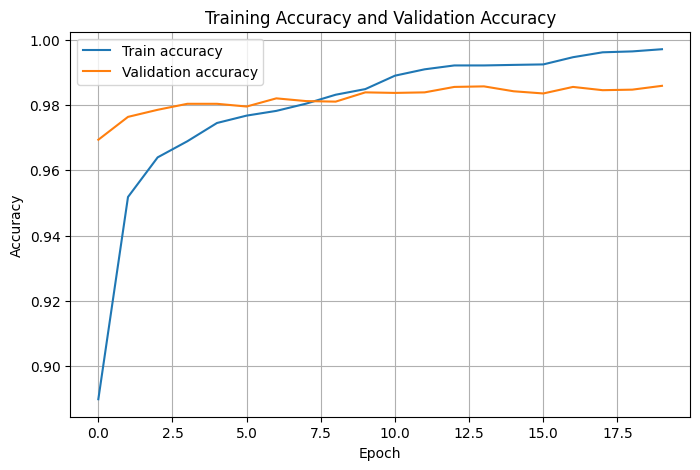

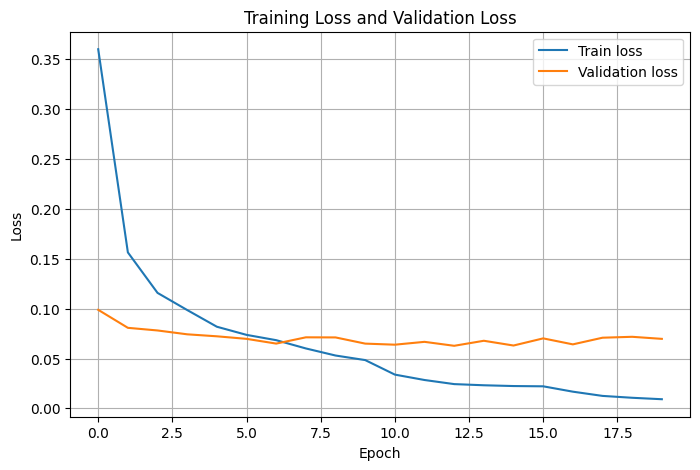

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification report:
              precision    recall  f1-score   support

        Số 0       0.99      0.99      0.99       980
        Số 1       0.99      0.99      0.99      1135
        Số 2       0.98      0.99      0.98      1032
        Số 3       0.98      0.98      0.98      1010
        Số 4       0.98      0.99      0.98       982
        Số 5       0.98      0.98      0.98       892
        Số 6       0.99      0.99      0.99       958
        Số 7       0.98      0.98      0.98      1028
        Số 8       0.97      0.98      0.97       974
        Số 9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Confusion matrix:
[[ 969    1    0    1    0    1    4    0    3    1]
 [   0 1126    3    0    0    1    2    0    3    0]
 [   1    0 1019    1    1    0    0    5    5    0]


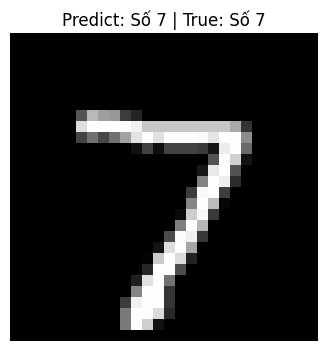

Đã lưu mô hình:
/content/final_mnist_ann_model.keras
/content/best_mnist_ann_model.keras


In [ ]:
# ============================================================
# BÀI 2: CÀI ĐẶT ANN NHẬN DẠNG CHỮ SỐ VIẾT TAY MNIST
# ============================================================

# =========================
# 1. Import thư viện
# =========================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix


# =========================
# 2. Cố định seed để kết quả ổn định hơn
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================
# 3. Khai báo đường dẫn dữ liệu
# =========================

train_path = "/content/mnist_train.csv"
test_path = "/content/mnist_test.csv"


# =========================
# 4. Tạo file CSV nếu chưa có
# =========================
# Nếu giảng viên đã cung cấp file, hãy upload file lên Colab
# đúng tên mnist_train.csv và mnist_test.csv.
# Nếu chưa có file, đoạn này tự tạo dữ liệu MNIST chuẩn từ TensorFlow.

def create_mnist_csv_if_missing(train_path, test_path):
    if os.path.exists(train_path) and os.path.exists(test_path):
        print("Đã tìm thấy file MNIST CSV.")
        return

    print("Chưa tìm thấy file CSV. Tiến hành tạo file từ tensorflow.keras.datasets.mnist...")

    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

    X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], 28 * 28)
    X_test_flat = X_test_raw.reshape(X_test_raw.shape[0], 28 * 28)

    train_data = np.column_stack((y_train_raw, X_train_flat))
    test_data = np.column_stack((y_test_raw, X_test_flat))

    np.savetxt(train_path, train_data, fmt="%d", delimiter=",")
    np.savetxt(test_path, test_data, fmt="%d", delimiter=",")

    print("Đã tạo xong:")
    print(train_path)
    print(test_path)


create_mnist_csv_if_missing(train_path, test_path)


# =========================
# 5. Hàm đọc dữ liệu MNIST CSV
# =========================

def read_mnist_csv(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

    df = pd.read_csv(file_path, header=None)

    # Nếu dòng đầu là header chữ, loại bỏ
    first_row_is_numeric = pd.to_numeric(df.iloc[0], errors="coerce").notna().all()

    if not first_row_is_numeric:
        df = df.iloc[1:].reset_index(drop=True)

    df = df.apply(pd.to_numeric)

    if df.shape[1] != 785:
        raise ValueError(
            f"File {file_path} phải có 785 cột: 1 cột label + 784 cột pixel. "
            f"Hiện tại có {df.shape[1]} cột."
        )

    y = df.iloc[:, 0].astype("int64").values
    X = df.iloc[:, 1:].astype("float32").values

    return X, y


# =========================
# 6. Đọc dữ liệu train/test
# =========================

X_train, y_train = read_mnist_csv(train_path)
X_test, y_test = read_mnist_csv(test_path)


# =========================
# 7. Khai báo nhãn
# =========================

class_names = [
    "Số 0",
    "Số 1",
    "Số 2",
    "Số 3",
    "Số 4",
    "Số 5",
    "Số 6",
    "Số 7",
    "Số 8",
    "Số 9"
]


# =========================
# 8. Kiểm tra dữ liệu ban đầu
# =========================

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Pixel min:", X_train.min())
print("Pixel max:", X_train.max())

print("Nhãn train:", np.unique(y_train))
print("Nhãn test:", np.unique(y_test))


# =========================
# 9. Chuẩn hóa dữ liệu
# =========================

X_train = X_train / 255.0
X_test = X_test / 255.0


# =========================
# 10. Hiển thị một số ảnh mẫu
# =========================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# 11. Xây dựng mô hình ANN tối ưu
# =========================

ann_model = Sequential([
    Input(shape=(784,)),

    Dense(512, activation="relu", kernel_initializer="he_normal"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(256, activation="relu", kernel_initializer="he_normal"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(128, activation="relu", kernel_initializer="he_normal"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(64, activation="relu", kernel_initializer="he_normal"),

    Dense(10, activation="softmax")
])


# =========================
# 12. Compile mô hình
# =========================

ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# =========================
# 13. Xem kiến trúc mô hình
# =========================

ann_model.summary()


# =========================
# 14. Callback tối ưu quá trình học
# =========================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="/content/best_mnist_ann_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)


# =========================
# 15. Huấn luyện mô hình
# =========================

history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)


# =========================
# 16. Đánh giá mô hình trên tập test
# =========================

test_loss, test_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


# =========================
# 17. Vẽ biểu đồ Accuracy
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 18. Vẽ biểu đồ Loss
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 19. Dự đoán tập test
# =========================

y_pred_prob = ann_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)


# =========================
# 20. Báo cáo phân loại
# =========================

print("Classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


# =========================
# 21. Ma trận nhầm lẫn
# =========================

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)


# =========================
# 22. Dự đoán một ảnh bất kỳ
# =========================

index = 0

sample = X_test[index].reshape(1, 784)

prediction = ann_model.predict(sample)
predicted_label = np.argmax(prediction)

print("Nhãn dự đoán:", predicted_label, "-", class_names[predicted_label])
print("Nhãn thật:", y_test[index], "-", class_names[y_test[index]])

plt.figure(figsize=(4, 4))
plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
plt.title(
    "Predict: " + class_names[predicted_label] +
    " | True: " + class_names[y_test[index]]
)
plt.axis("off")
plt.show()


# =========================
# 23. Lưu mô hình cuối cùng
# =========================

ann_model.save("/content/final_mnist_ann_model.keras")

print("Đã lưu mô hình:")
print("/content/final_mnist_ann_model.keras")
print("/content/best_mnist_ann_model.keras")

3. Cho đoạn mã đọc ảnh của Cat và Dog

Số ảnh Cat dùng: 1000
Số ảnh Dog dùng: 1000
Đã tạo thư mục: /content/train
Số file cats: 1000
Số file dogs: 1000
Tổng số ảnh đọc được: 2000
Số ảnh bị bỏ qua: 0
photos shape: (2000, 200, 200, 3)
labels shape: (2000,)
Số ảnh Cat: 1000
Số ảnh Dog: 1000
Đã lưu file:
/content/dogs_vs_cats_photos.npy
/content/dogs_vs_cats_labels.npy


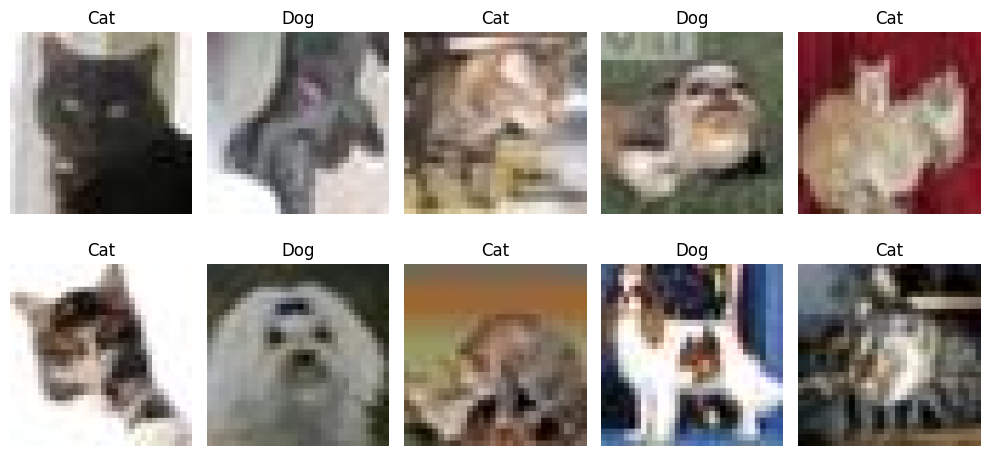

In [ ]:
# ============================================================
# BÀI 3: TẠO DATASET CAT/DOG TỪ CIFAR-10, ĐỌC ẢNH VÀ LƯU .NPY
# ============================================================

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import load_img, img_to_array


# =========================
# 1. Cấu hình
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "/content/train"
CAT_DIR = os.path.join(DATA_DIR, "cats")
DOG_DIR = os.path.join(DATA_DIR, "dogs")

IMG_SIZE = (200, 200)

MAX_PER_CLASS = 1000

PHOTOS_SAVE_PATH = "/content/dogs_vs_cats_photos.npy"
LABELS_SAVE_PATH = "/content/dogs_vs_cats_labels.npy"


# =========================
# 2. Tạo thư mục /content/train
# =========================

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)

os.makedirs(CAT_DIR, exist_ok=True)
os.makedirs(DOG_DIR, exist_ok=True)


# =========================
# 3. Đọc CIFAR-10
# =========================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0).reshape(-1)


# =========================
# 4. Lọc ảnh Cat và Dog
# =========================
# CIFAR-10:
# 3 = cat
# 5 = dog

cat_images = X_all[y_all == 3]
dog_images = X_all[y_all == 5]

cat_images = cat_images[:MAX_PER_CLASS]
dog_images = dog_images[:MAX_PER_CLASS]

print("Số ảnh Cat dùng:", len(cat_images))
print("Số ảnh Dog dùng:", len(dog_images))


# =========================
# 5. Lưu ảnh ra thư mục dạng .jpg
# =========================

for i, img_array in enumerate(cat_images):
    img = Image.fromarray(img_array)
    img.save(os.path.join(CAT_DIR, f"cat_{i}.jpg"))

for i, img_array in enumerate(dog_images):
    img = Image.fromarray(img_array)
    img.save(os.path.join(DOG_DIR, f"dog_{i}.jpg"))

print("Đã tạo thư mục:", DATA_DIR)
print("Số file cats:", len(os.listdir(CAT_DIR)))
print("Số file dogs:", len(os.listdir(DOG_DIR)))


# =========================
# 6. Hàm xác định nhãn ảnh
# =========================

def get_label_from_filename(file_path):
    file_name = os.path.basename(file_path).lower()
    parent_name = os.path.basename(os.path.dirname(file_path)).lower()

    if file_name.startswith("cat") or parent_name in ["cat", "cats"]:
        return 0

    if file_name.startswith("dog") or parent_name in ["dog", "dogs"]:
        return 1

    return None


# =========================
# 7. Hàm lấy danh sách ảnh
# =========================

def get_image_files(data_dir):
    valid_extensions = (".jpg", ".jpeg", ".png")
    image_files = []

    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(valid_extensions):
                image_files.append(os.path.join(root, file))

    return image_files


# =========================
# 8. Đọc ảnh, resize, chuyển NumPy array
# =========================

def load_cat_dog_dataset(data_dir, img_size):
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Không tìm thấy thư mục dataset: {data_dir}")

    image_files = get_image_files(data_dir)

    if len(image_files) == 0:
        raise ValueError(f"Không tìm thấy ảnh trong thư mục: {data_dir}")

    photos = []
    labels = []
    skipped = 0

    for file_path in image_files:
        label = get_label_from_filename(file_path)

        if label is None:
            skipped += 1
            continue

        try:
            img = load_img(
                file_path,
                color_mode="rgb",
                target_size=img_size
            )

            img_array = img_to_array(img)

            photos.append(img_array)
            labels.append(label)

        except Exception as e:
            skipped += 1
            print("Bỏ qua ảnh lỗi:", file_path)
            print("Lỗi:", e)

    photos = np.asarray(photos, dtype="uint8")
    labels = np.asarray(labels, dtype="int64")

    return photos, labels, skipped


# =========================
# 9. Chạy đọc dataset
# =========================

photos, labels, skipped = load_cat_dog_dataset(DATA_DIR, IMG_SIZE)

print("Tổng số ảnh đọc được:", len(photos))
print("Số ảnh bị bỏ qua:", skipped)
print("photos shape:", photos.shape)
print("labels shape:", labels.shape)
print("Số ảnh Cat:", np.sum(labels == 0))
print("Số ảnh Dog:", np.sum(labels == 1))


# =========================
# 10. Shuffle dữ liệu
# =========================

indices = np.arange(len(photos))
np.random.shuffle(indices)

photos = photos[indices]
labels = labels[indices]


# =========================
# 11. Lưu thành file .npy
# =========================

np.save(PHOTOS_SAVE_PATH, photos)
np.save(LABELS_SAVE_PATH, labels)

print("Đã lưu file:")
print(PHOTOS_SAVE_PATH)
print(LABELS_SAVE_PATH)


# =========================
# 12. Hiển thị vài ảnh mẫu
# =========================

class_names = ["Cat", "Dog"]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(photos[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Đang tải CIFAR-10...
Số ảnh Cat: 1000
Số ảnh Dog: 1000
Đã tạo xong dataset tại: /content/train
Số file cats: 1000
Số file dogs: 1000
Tổng số ảnh đọc được: 2000
Số ảnh bị bỏ qua: 0
photos shape: (2000, 200, 200, 3)
labels shape: (2000,)
Số ảnh Cat: 1000
Số ảnh Dog: 1000
Đã lưu file:
/content/dogs_vs_cats_photos.npy
/content/dogs_vs_cats_labels.npy
photos_loaded shape: (2000, 200, 200, 3)
labels_loaded shape: (2000,)


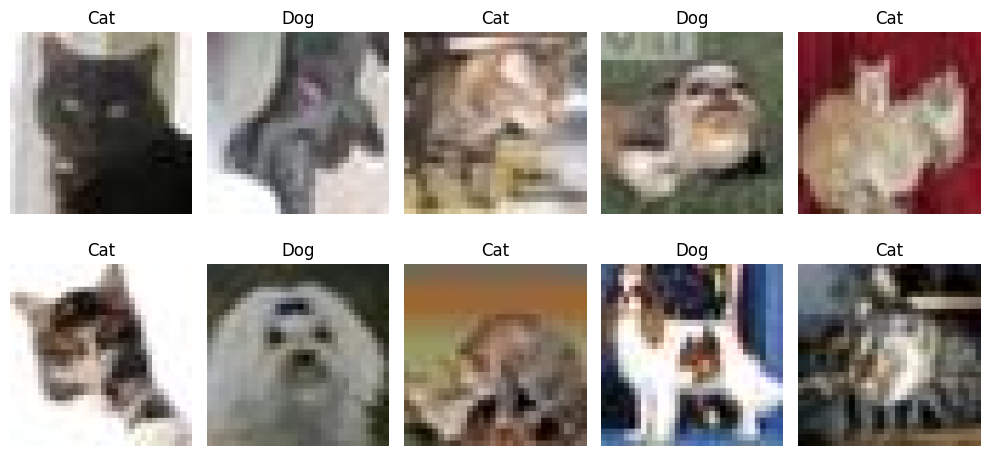

In [ ]:
# ============================================================
# BÀI 3: ĐỌC ẢNH CAT/DOG, RESIZE VÀ LƯU THÀNH FILE .NPY
# ============================================================

# =========================
# 1. Import thư viện
# =========================

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import load_img, img_to_array


# =========================
# 2. Cấu hình
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Thư mục chứa ảnh Cat/Dog
DATA_DIR = "/content/train"
CAT_DIR = os.path.join(DATA_DIR, "cats")
DOG_DIR = os.path.join(DATA_DIR, "dogs")

# Resize ảnh theo đề bài
IMG_SIZE = (200, 200)

# Số ảnh mỗi lớp lấy từ CIFAR-10
MAX_PER_CLASS = 1000

# File output
PHOTOS_SAVE_PATH = "/content/dogs_vs_cats_photos.npy"
LABELS_SAVE_PATH = "/content/dogs_vs_cats_labels.npy"


# =========================
# 3. Tạo dataset Cat/Dog từ CIFAR-10
# =========================

def create_cat_dog_dataset_from_cifar10():
    """
    Tạo thư mục:
    /content/train/cats
    /content/train/dogs

    CIFAR-10 labels:
    3 = cat
    5 = dog
    """

    if os.path.exists(DATA_DIR):
        shutil.rmtree(DATA_DIR)

    os.makedirs(CAT_DIR, exist_ok=True)
    os.makedirs(DOG_DIR, exist_ok=True)

    print("Đang tải CIFAR-10...")

    (X_train, y_train), (X_test, y_test) = cifar10.load_data()

    X_all = np.concatenate([X_train, X_test], axis=0)
    y_all = np.concatenate([y_train, y_test], axis=0).reshape(-1)

    cat_images = X_all[y_all == 3]
    dog_images = X_all[y_all == 5]

    cat_images = cat_images[:MAX_PER_CLASS]
    dog_images = dog_images[:MAX_PER_CLASS]

    print("Số ảnh Cat:", len(cat_images))
    print("Số ảnh Dog:", len(dog_images))

    for i, img_array in enumerate(cat_images):
        img = Image.fromarray(img_array)
        img.save(os.path.join(CAT_DIR, f"cat_{i}.jpg"))

    for i, img_array in enumerate(dog_images):
        img = Image.fromarray(img_array)
        img.save(os.path.join(DOG_DIR, f"dog_{i}.jpg"))

    print("Đã tạo xong dataset tại:", DATA_DIR)
    print("Số file cats:", len(os.listdir(CAT_DIR)))
    print("Số file dogs:", len(os.listdir(DOG_DIR)))


create_cat_dog_dataset_from_cifar10()


# =========================
# 4. Hàm xác định nhãn ảnh
# =========================

def get_label_from_filename(file_path):
    """
    Quy ước:
    Cat = 0
    Dog = 1
    """

    file_name = os.path.basename(file_path).lower()
    parent_name = os.path.basename(os.path.dirname(file_path)).lower()

    if file_name.startswith("cat") or parent_name in ["cat", "cats"]:
        return 0

    if file_name.startswith("dog") or parent_name in ["dog", "dogs"]:
        return 1

    return None


# =========================
# 5. Hàm lấy danh sách ảnh
# =========================

def get_image_files(data_dir):
    valid_extensions = (".jpg", ".jpeg", ".png")
    image_files = []

    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(valid_extensions):
                image_files.append(os.path.join(root, file))

    return image_files


# =========================
# 6. Hàm đọc ảnh và chuyển thành NumPy array
# =========================

def load_cat_dog_dataset(data_dir, img_size):
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Không tìm thấy thư mục dataset: {data_dir}")

    image_files = get_image_files(data_dir)

    if len(image_files) == 0:
        raise ValueError(f"Không tìm thấy ảnh trong thư mục: {data_dir}")

    photos = []
    labels = []
    skipped = 0

    for file_path in image_files:
        label = get_label_from_filename(file_path)

        if label is None:
            skipped += 1
            continue

        try:
            photo = load_img(
                file_path,
                color_mode="rgb",
                target_size=img_size
            )

            photo = img_to_array(photo)

            photos.append(photo)
            labels.append(label)

        except Exception as e:
            skipped += 1
            print("Bỏ qua ảnh lỗi:", file_path)
            print("Lỗi:", e)

    photos = np.asarray(photos, dtype="uint8")
    labels = np.asarray(labels, dtype="int64")

    if len(photos) == 0:
        raise ValueError("Không đọc được ảnh hợp lệ nào.")

    return photos, labels, skipped


# =========================
# 7. Đọc dataset Cat/Dog
# =========================

photos, labels, skipped = load_cat_dog_dataset(DATA_DIR, IMG_SIZE)

print("Tổng số ảnh đọc được:", len(photos))
print("Số ảnh bị bỏ qua:", skipped)
print("photos shape:", photos.shape)
print("labels shape:", labels.shape)
print("Số ảnh Cat:", np.sum(labels == 0))
print("Số ảnh Dog:", np.sum(labels == 1))


# =========================
# 8. Shuffle dữ liệu
# =========================

indices = np.arange(len(photos))
np.random.shuffle(indices)

photos = photos[indices]
labels = labels[indices]


# =========================
# 9. Lưu dữ liệu thành file .npy
# =========================

np.save(PHOTOS_SAVE_PATH, photos)
np.save(LABELS_SAVE_PATH, labels)

print("Đã lưu file:")
print(PHOTOS_SAVE_PATH)
print(LABELS_SAVE_PATH)


# =========================
# 10. Kiểm tra lại file .npy
# =========================

photos_loaded = np.load(PHOTOS_SAVE_PATH)
labels_loaded = np.load(LABELS_SAVE_PATH)

print("photos_loaded shape:", photos_loaded.shape)
print("labels_loaded shape:", labels_loaded.shape)


# =========================
# 11. Hiển thị một số ảnh mẫu
# =========================

class_names = ["Cat", "Dog"]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(photos_loaded[i])
    plt.title(class_names[labels_loaded[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

4. Viết chương trình cài đặt ANN để dự báo thu nhập một người > 50K/năm hay <= 50K/năm (nhãn
cuối) theo bộ dữ liệu adult do giảng viên cung cấp

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print("File đã upload:", file_name)

Saving adult_synthetic.csv to adult_synthetic.csv
File đã upload: adult_synthetic.csv


In [ ]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

df = pd.read_csv(
    file_name,
    header=None,
    names=columns,
    na_values="?",
    skipinitialspace=True
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
1,58,Private,28663,Assoc-voc,11,Never-married,Exec-managerial,Own-child,White,Male,0,1092,46,United-States,<=50K
2,62,Private,93516,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Female,0,0,43,United-States,>50K
3,40,Private,336282,Assoc-acdm,12,Married-civ-spouse,Other-service,Wife,White,Male,0,0,46,Vietnam,<=50K
4,67,Private,121842,10th,6,Never-married,Adm-clerical,Own-child,White,Male,0,0,33,United-States,<=50K


In [ ]:
print("Kích thước dữ liệu:", df.shape)
print("\nThông tin dữ liệu:")
print(df.info())

print("\nSố lượng giá trị thiếu:")
print(df.isnull().sum())

print("\nPhân bố nhãn:")
print(df.iloc[:, -1].value_counts())

Kích thước dữ liệu: (1001, 15)

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             1001 non-null   object
 1   workclass       1001 non-null   object
 2   fnlwgt          1001 non-null   object
 3   education       1001 non-null   object
 4   education-num   1001 non-null   object
 5   marital-status  1001 non-null   object
 6   occupation      1001 non-null   object
 7   relationship    1001 non-null   object
 8   race            1001 non-null   object
 9   sex             1001 non-null   object
 10  capital-gain    1001 non-null   object
 11  capital-loss    1001 non-null   object
 12  hours-per-week  1001 non-null   object
 13  native-country  1001 non-null   object
 14  income          1001 non-null   object
dtypes: object(15)
memory usage: 117.4+ KB
None

Số lượng giá trị thiếu:
age               0
w

In [ ]:
# Xóa khoảng trắng thừa ở các cột dạng chuỗi
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].str.strip()

# Chuẩn hóa nhãn: bỏ dấu chấm nếu có, ví dụ >50K. -> >50K
label_col = df.columns[-1]
df[label_col] = df[label_col].str.replace(".", "", regex=False)

# Xóa các dòng bị thiếu dữ liệu
df = df.dropna()

print("Kích thước sau khi làm sạch:", df.shape)
print(df[label_col].value_counts())

Kích thước sau khi làm sạch: (1001, 15)
income
<=50K     732
>50K      268
income      1
Name: count, dtype: int64


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Mã hóa nhãn
y = y.map({
    "<=50K": 0,
    ">50K": 1
})

print("Kiểm tra nhãn sau mã hóa:")
print(y.value_counts())

Kiểm tra nhãn sau mã hóa:
income
0.0    732
1.0    268
Name: count, dtype: int64


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Cột số:", numeric_features)
print("Cột phân loại:", categorical_features)

Cột số: []
Cột phân loại: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

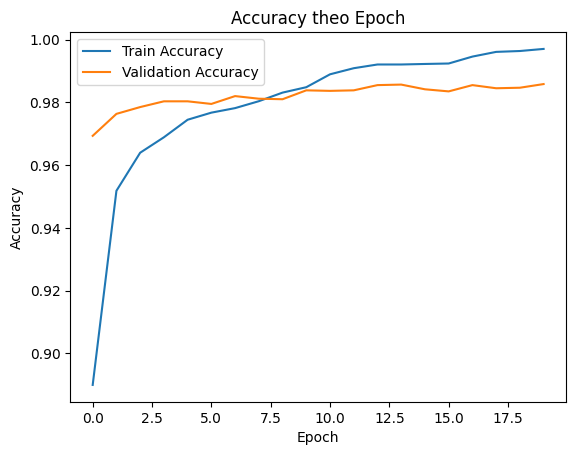

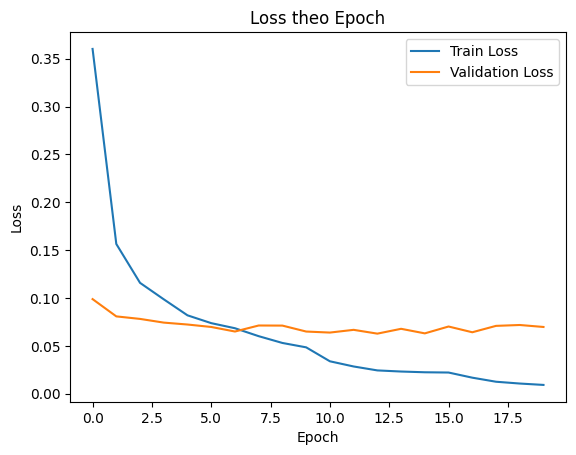

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy theo Epoch")
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss theo Epoch")
plt.show()

photos shape: (2000, 200, 200, 3)
labels shape: (2000,)
Kiểu dữ liệu ảnh: uint8
Số ảnh Cat: 1000
Số ảnh Dog: 1000
X shape: (2000, 200, 200, 3)
y shape: (2000,)
X_train shape: (1600, 200, 200, 3)
X_test shape: (400, 200, 200, 3)
y_train shape: (1600,)
y_test shape: (400,)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 120000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │    15,360,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,370,497 (58.63 MB)

 Trainable params: 15,370,497 (58.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 332ms/step - accuracy: 0.5164 - loss: 8.3514 - val_accuracy: 0.4812 - val_loss: 1.0160
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 286ms/step - accuracy: 0.5023 - loss: 1.2550 - val_accuracy: 0.4594 - val_loss: 0.6949
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 399ms/step - accuracy: 0.5195 - loss: 0.6916 - val_accuracy: 0.4750 - val_loss: 0.6945
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 295ms/step - accuracy: 0.5328 - loss: 0.6902 - val_accuracy: 0.5031 - val_loss: 0.6905
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 293ms/step - accuracy: 0.5125 - loss: 0.6924 - val_accuracy: 0.4563 - val_loss: 0.6955
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.5109 - loss: 0.6932 - val_accuracy: 0.4563 - val_loss: 0.6951
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 293ms/step - accuracy: 0.5109 - loss: 0.6931 - val_accuracy: 0.4563 - val_loss: 0.6950
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 296ms/step - accuracy: 0.5109 - loss: 0.6926 - val_accu

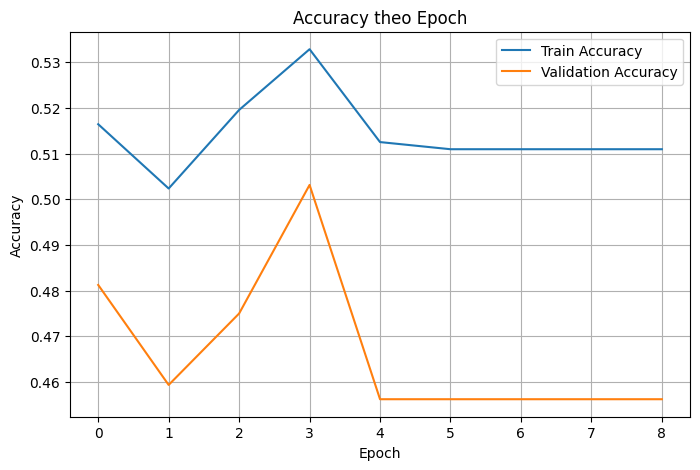

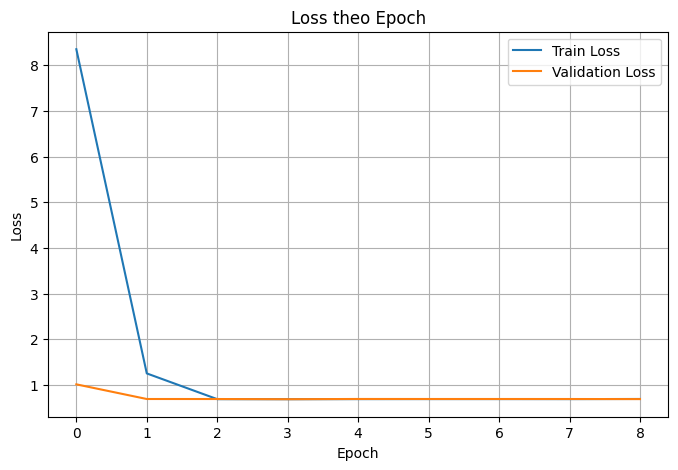

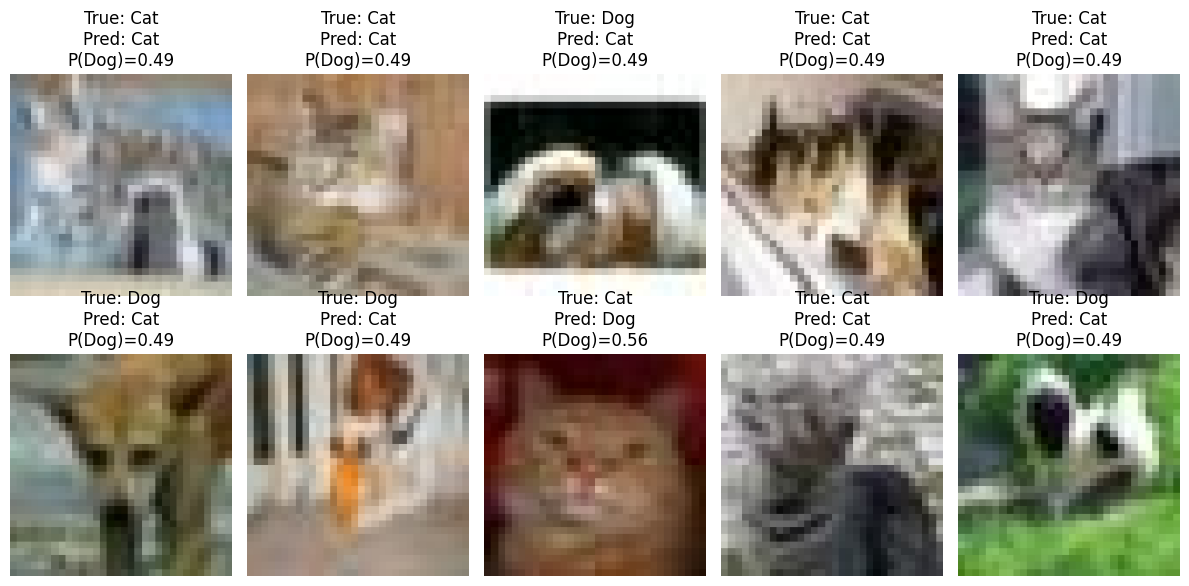

Đã lưu mô hình: /content/ann_cat_dog_model.h5


In [ ]:
# ============================================================
# BÀI 3: CÀI ĐẶT ANN NHẬN DẠNG ẢNH CAT / DOG
# ============================================================

# =========================
# 1. Import thư viện
# =========================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# =========================
# 2. Cố định seed
# =========================

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================
# 3. Load dữ liệu .npy
# =========================

PHOTOS_PATH = "/content/dogs_vs_cats_photos.npy"
LABELS_PATH = "/content/dogs_vs_cats_labels.npy"

photos = np.load(PHOTOS_PATH)
labels = np.load(LABELS_PATH)

print("photos shape:", photos.shape)
print("labels shape:", labels.shape)
print("Kiểu dữ liệu ảnh:", photos.dtype)
print("Số ảnh Cat:", np.sum(labels == 0))
print("Số ảnh Dog:", np.sum(labels == 1))


# =========================
# 4. Tiền xử lý dữ liệu
# =========================
# Ảnh ban đầu có giá trị pixel từ 0 đến 255
# Chuẩn hóa về khoảng [0, 1]

X = photos.astype("float32") / 255.0
y = labels.astype("int64")

print("X shape:", X.shape)
print("y shape:", y.shape)


# =========================
# 5. Chia train / test
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# =========================
# 6. Xây dựng mô hình ANN
# =========================

model = Sequential([
    Input(shape=(200, 200, 3)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.summary()


# =========================
# 7. Compile mô hình
# =========================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# =========================
# 8. Huấn luyện mô hình
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# =========================
# 9. Đánh giá mô hình trên tập test
# =========================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


# =========================
# 10. Dự đoán trên tập test
# =========================

y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype("int64").reshape(-1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Cat", "Dog"]
))


# =========================
# 11. Vẽ biểu đồ Accuracy và Loss
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy theo Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss theo Epoch")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 12. Hiển thị một số ảnh dự đoán
# =========================

class_names = ["Cat", "Dog"]

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])

    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred[i]]
    prob = y_prob[i][0]

    plt.title(f"True: {true_label}\nPred: {pred_label}\nP(Dog)={prob:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# 13. Lưu mô hình
# =========================

model.save("/content/ann_cat_dog_model.h5")
print("Đã lưu mô hình: /content/ann_cat_dog_model.h5")

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_cat_dog(image_path, model):
    img = load_img(
        image_path,
        color_mode="rgb",
        target_size=(200, 200)
    )

    img_array = img_to_array(img)
    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob = model.predict(img_array)[0][0]

    if prob >= 0.5:
        label = "Dog"
    else:
        label = "Cat"

    print("Ảnh dự đoán là:", label)
    print("Xác suất Dog:", prob)

    return label, prob

In [ ]:
predict_cat_dog("/content/train/cats/cat_0.jpg", model)
predict_cat_dog("/content/train/dogs/dog_0.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Ảnh dự đoán là: Cat
Xác suất Dog: 0.4876188
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Ảnh dự đoán là: Cat
Xác suất Dog: 0.4876188


('Cat', np.float32(0.4876188))

5. Viết chương trình cài đặt ANN để dự báo việc đánh giá chất lượng xe ô tô (nhãn cuối) từ bộ dữ liệu
car do giảng viên cung cấp.

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import matplotlib.pyplot as plt

In [ ]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print("File đã upload:", file_name)

Saving car_synthetic.csv to car_synthetic.csv
File đã upload: car_synthetic.csv


In [ ]:
car_columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

df = pd.read_csv(
    file_name,
    header=None,
    skipinitialspace=True
)

# Nếu dòng đầu là header thì loại bỏ dòng đó
first_row = df.iloc[0].astype(str).str.strip().str.lower().tolist()

possible_header_words = [
    "buying", "maint", "doors", "persons",
    "lug_boot", "safety", "class", "label", "target"
]

if any(value in possible_header_words for value in first_row):
    df = df.iloc[1:].reset_index(drop=True)

# Gán tên cột nếu dữ liệu có đúng 7 cột
if df.shape[1] == 7:
    df.columns = car_columns
else:
    raise ValueError(f"Dữ liệu đang có {df.shape[1]} cột, không đúng cấu trúc car chuẩn gồm 7 cột.")

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Các cột đặc trưng:")
print(X.columns.tolist())

print("\nCác nhãn ban đầu:")
print(y.unique())

Các cột đặc trưng:
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

Các nhãn ban đầu:
['unacc' 'acc' 'vgood' 'good']


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Mapping nhãn:")
for index, label in enumerate(label_encoder.classes_):
    print(index, "->", label)

print("\nSố lớp:", len(label_encoder.classes_))

Mapping nhãn:
0 -> acc
1 -> good
2 -> unacc
3 -> vgood

Số lớp: 4


In [ ]:
categorical_features = X.columns.tolist()

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", one_hot_encoder, categorical_features)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1382, 6)
Test: (346, 6)


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Số đặc trưng sau One-Hot Encoding:", X_train_processed.shape[1])

Số đặc trưng sau One-Hot Encoding: 21


In [ ]:
input_dim = X_train_processed.shape[1]
num_classes = len(label_encoder.classes_)

model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(input_dim,)))
model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))

# Vì đây là bài toán phân loại đa lớp
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,084 (15.95 KB)

 Trainable params: 4,084 (15.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6561 - loss: 1.0268 - val_accuracy: 0.6643 - val_loss: 0.7643
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7095 - loss: 0.6049 - val_accuracy: 0.7726 - val_loss: 0.4776
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8443 - loss: 0.3986 - val_accuracy: 0.8881 - val_loss: 0.3263
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8842 - loss: 0.3035 - val_accuracy: 0.9061 - val_loss: 0.2588
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9023 - loss: 0.2462 - val_accuracy: 0.9061 - val_loss: 0.2164
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9222 - loss: 0.2199 - val_accuracy: 0.9531 - val_loss: 0.1824
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9240 - loss: 0.2022 - val_accuracy: 0.9458 - val_loss: 0.1661
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.1872 - val_accuracy: 0.9639 - val_los

In [ ]:
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)

print("Loss trên tập test:", loss)
print("Accuracy trên tập test:", accuracy)

Loss trên tập test: 0.050882454961538315
Accuracy trên tập test: 0.9884393215179443


In [ ]:
y_pred_prob = model.predict(X_test_processed)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Accuracy: 0.9884393063583815

Confusion Matrix:
[[ 91   0   0   0]
 [  4  10   0   0]
 [  0   0 238   0]
 [  0   0   0   3]]

Classification Report:
              precision    recall  f1-score   support

         acc       0.96      1.00      0.98        91
        good       1.00      0.71      0.83        14
       unacc       1.00      1.00      1.00       238
       vgood       1.00      1.00      1.00         3

    accuracy                           0.99       346
   macro avg       0.99      0.93      0.95       346
weighted avg       0.99      0.99      0.99       346



In [ ]:
cm_df = pd.DataFrame(
    cm,
    index=["Thực tế " + label for label in label_encoder.classes_],
    columns=["Dự báo " + label for label in label_encoder.classes_]
)

display(cm_df)

,Dự báo acc,Dự báo good,Dự báo unacc,Dự báo vgood
Thực tế acc,91,0,0,0
Thực tế good,4,10,0,0
Thực tế unacc,0,0,238,0
Thực tế vgood,0,0,0,3


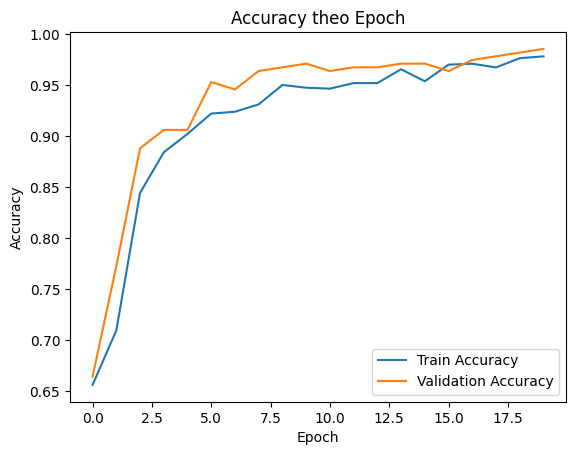

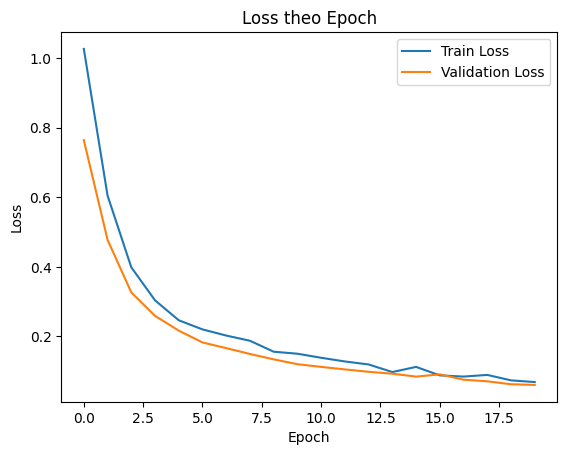

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy theo Epoch")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss theo Epoch")
plt.legend()
plt.show()

In [ ]:
new_car = pd.DataFrame([{
    "buying": "low",
    "maint": "low",
    "doors": "4",
    "persons": "4",
    "lug_boot": "big",
    "safety": "high"
}])

new_car_processed = preprocessor.transform(new_car)

pred_prob = model.predict(new_car_processed)
pred_class_index = np.argmax(pred_prob, axis=1)[0]
pred_label = label_encoder.inverse_transform([pred_class_index])[0]

print("Xác suất từng lớp:")
for label, prob in zip(label_encoder.classes_, pred_prob[0]):
    print(label, ":", prob)

print("\nDự báo đánh giá xe:", pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Xác suất từng lớp:
acc : 0.0395034
good : 0.85595095
unacc : 0.0017172275
vgood : 0.102828436

Dự báo đánh giá xe: good


 Triển khai câu 5 trên nền tảng Web sử dụng Flask